<a href="https://colab.research.google.com/github/HTKhuongNinh-FPTU/Machine-Learning-Doc/blob/main/PhongShading.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

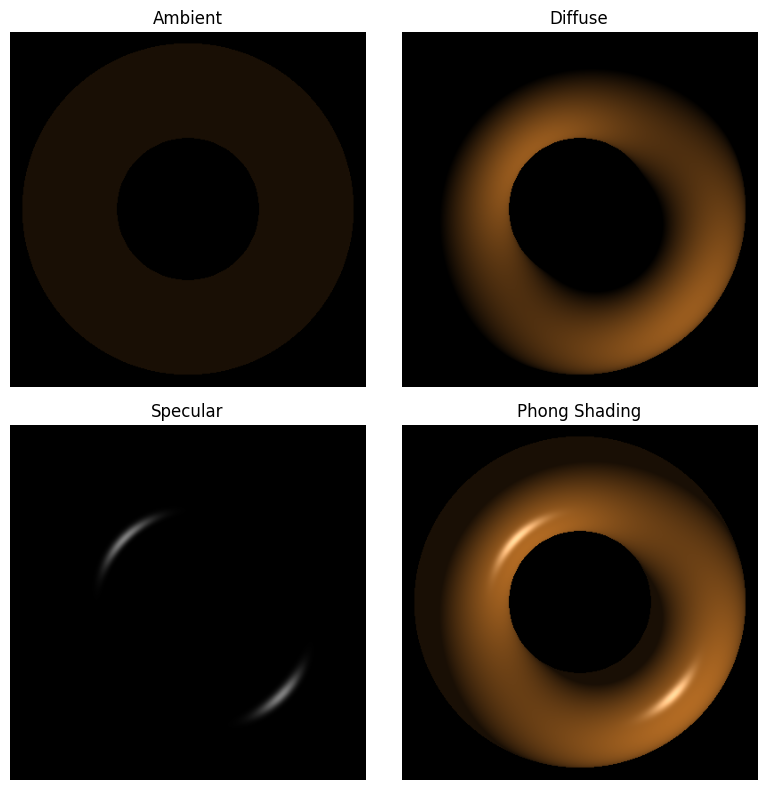

In [33]:
import numpy as np
import matplotlib.pyplot as plt

# Khởi tạo hình học
H, W = 400, 400
y, x = np.ogrid[-1.5:1.5:H*1j, -1.5:1.5:W*1j]

R_major = 1.0
r_minor = 0.4

rho = np.sqrt(x**2 + y**2)
z_sq = r_minor**2 - (R_major - rho)**2
mask = z_sq >= 0

z = np.zeros_like(z_sq)
z[mask] = np.sqrt(z_sq[mask])
# Tính Pháp tuyến N
n_raw_x = (x / rho) * (rho - R_major)
n_raw_y = (y / rho) * (rho - R_major)
n_raw_z = z
norm = np.sqrt(n_raw_x**2 + n_raw_y**2 + n_raw_z**2 + 1e-10)
N = np.stack([n_raw_x/norm, n_raw_y/norm, n_raw_z/norm], axis=-1)
N[~mask] = 0

# Thiết lập nguồn sáng và hướng nhìn
light_pos = np.array([2.0, 2.0, 2.0]) # Q3
view_pos  = np.array([0.0, 0.0, 5.0])

# Tạo tọa độ 3D
coords = np.stack([np.broadcast_to(x, (H, W)), np.broadcast_to(y, (H, W)), z], axis=-1)

L = (light_pos - coords)
L /= np.linalg.norm(L, axis=-1, keepdims=True)

V = (view_pos - coords)
V /= np.linalg.norm(V, axis=-1, keepdims=True)

# Tính toán Phong Shading
ka, kd, ks, shininess = 0.1, 0.6, 0.5, 32  # Q1,Q2
donut_color = np.array([1.0, 0.6, 0.2])
light_color = np.array([1.0, 1.0, 1.0])

# Ambient
ambient = ka * donut_color * light_color
ambient_img = np.zeros((H, W, 3))
ambient_img[mask] = ambient

# Diffuse
N_dot_L = np.maximum(np.sum(N * L, axis=-1), 0)[..., np.newaxis]
diffuse = kd * N_dot_L * donut_color * light_color
diffuse_img = np.zeros((H, W, 3))
diffuse_img[mask] = diffuse[mask]

# Specular
R = 2 * np.sum(N * L, axis=-1)[..., np.newaxis] * N - L
R_dot_V = np.maximum(np.sum(R * V, axis=-1), 0)[..., np.newaxis]
specular = ks * np.power(R_dot_V, shininess) * light_color
specular_img = np.zeros((H, W, 3))
specular_img[mask] = specular[mask]

final = (ambient + diffuse + specular)
final_img = np.zeros((H, W, 3))
final_img[mask] = np.clip(final[mask], 0, 1)

# Show
plt.figure(figsize=(8,8))
for i, (img, title) in enumerate(zip([ambient_img, diffuse_img, specular_img, final_img],
                                     ['Ambient', 'Diffuse', 'Specular', 'Phong Shading'])):
    plt.subplot(2, 2, i+1)
    plt.imshow(img)
    plt.title(title)
    plt.axis('off')
plt.tight_layout()
plt.show()

1. Khi tăng shininess từ 32 lên 128: Điểm sáng phản chiếu (highlight) sẽ trở nên nhỏ hơn, tập trung hơn và sắc nét hơn. Điều này xảy ra vì hàm lũy thừa (np.power) với số mũ lớn hơn sẽ triệt tiêu nhanh hơn các giá trị tích vô hướng không gần bằng 1, chỉ giữ lại các vùng rất gần với hướng phản chiếu lý tưởng.
2. Nếu đặt ks = 0: Thành phần Specular (điểm chói) bị triệt tiêu hoàn toàn. Vật thể sẽ trông như làm bằng vật liệu nhám (matte) và mất đi độ bóng bẩy.
3. Thay đổi light_pos sang phía đối diện: Vùng sáng và điểm nhấn (highlight) sẽ dịch chuyển sang phía đối diện của vật thể, vì ánh sáng chiếu vào từ một góc độ khác.
4. Tại sao pháp tuyến $N$ cần chuẩn hóa: Vì mô hình Phong sử dụng tích vô hướng (dot product) để tính toán cường độ ánh sáng. Nếu $N$ không có độ dài đơn vị (bằng 1), giá trị tích vô hướng sẽ bị khuếch đại hoặc thu nhỏ bất thường, dẫn đến việc tính toán độ sáng tại các pixel bị sai lệch (quá sáng hoặc quá tối so với thực tế).